In [1]:
import pandas as pd

df=pd.read_csv("F:\churn_prediction\churn_data.csv")
print(df.head(5))
print(df.shape)


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
print(df.isnull())
print(df.isnull().sum())

      customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0          False   False          False    False       False   False   
1          False   False          False    False       False   False   
2          False   False          False    False       False   False   
3          False   False          False    False       False   False   
4          False   False          False    False       False   False   
...          ...     ...            ...      ...         ...     ...   
7038       False   False          False    False       False   False   
7039       False   False          False    False       False   False   
7040       False   False          False    False       False   False   
7041       False   False          False    False       False   False   
7042       False   False          False    False       False   False   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0            False          False            False          

In [5]:
print(df.describe())
print(df.info())
print(df.nunique())
print(df.head(5))

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines  

In [25]:
df1=df.drop('customerID', axis=1)

binary_cols=['Partner','PhoneService', 'OnlineSecurity',  'DeviceProtection', 'TechSupport',
             'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for cols in binary_cols:
    df1[cols]=df1[cols].map({'Yes':1, 'No':0})

df1['Contract']=df1['Contract'].map({'Yes':1, 'No':0})

df['MultipleLines']=df['MultipleLines'].replace({'No phone service': 'No'})
df['MultipleLines']=df['MultipleLines'].map({'No':0, 'Yes':1})

df1=pd.get_dummies(df1, columns=['PaymentMethod', 'Contract', 'InternetService'], drop_first=True)

bool_cols = df1.select_dtypes(include='bool').columns
df1[bool_cols] = df1[bool_cols].astype(int)

print(df1)

      gender  SeniorCitizen  Partner Dependents  tenure  PhoneService  \
0     Female              0        1         No       1             0   
1       Male              0        0         No      34             1   
2       Male              0        0         No       2             1   
3       Male              0        0         No      45             0   
4     Female              0        0         No       2             1   
...      ...            ...      ...        ...     ...           ...   
7038    Male              0        1        Yes      24             1   
7039  Female              0        1        Yes      72             1   
7040  Female              0        1        Yes      11             0   
7041    Male              1        1         No       4             1   
7042    Male              0        0         No      66             1   

      MultipleLines  OnlineSecurity OnlineBackup  DeviceProtection  ...  \
0               NaN             0.0          Yes

In [19]:
print(df1.info())
print(df1.isnull())
print(df1.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   object 
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   object 
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          0 non-null      float64
 7   OnlineSecurity                         5517 non-null   float64
 8   OnlineBackup                           7043 non-null   object 
 9   DeviceProtection                       5517 non-null   float64
 10  TechSupport                            5517 non-null   float64
 11  Stre

In [3]:
# Drop customerID
df1 = df.drop('customerID', axis=1)

# Fix columns with "No internet service"
internet_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in internet_cols:
    df1[col] = df1[col].replace({'No internet service': 'No'})

# Binary Yes/No columns
binary_cols = [
    'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'Churn'] + internet_cols

for col in binary_cols:
    df1[col] = df1[col].map({'Yes': 1, 'No': 0})

# Gender
df1['gender'] = df1['gender'].map({'Male': 1, 'Female': 0})

# MultipleLines fix
df1['MultipleLines'] = df1['MultipleLines'].replace({'No phone service': 'No'})
df1['MultipleLines'] = df1['MultipleLines'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding
df1 = pd.get_dummies(
    df1,
    columns=['PaymentMethod', 'Contract', 'InternetService'],drop_first=True)

bool_cols = df1.select_dtypes(include='bool').columns
df1[bool_cols] = df1[bool_cols].astype(int)

print(df1.head())


   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  ...  \
0              0               0             1                 0  ...   
1              0               1             0                 1  ...   
2              0               1             1                 0  ...   
3              0               1             0                 1  ...   
4              0               0             0                 0  ...   

   MonthlyCharges  TotalCharges  Churn  PaymentMethod_Credit card (automatic)  \
0           29.85         29.85      0               

In [36]:
print(df1.info())
print(df1.isnull())
print(df1.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          0 non-null      float64
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

In [24]:
# df1=df1.drop('MultipleLines', axis=1)
print(df1['TotalCharges'])
df1['TotalCharges'] = df1['TotalCharges'].replace(' ', 0)
print(df1.loc[488, 'TotalCharges'])


0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: object
0


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X=df1.drop(['Churn'], axis=1)
y=df1['Churn']

X_train, X_test, y_train, y_test =  train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42, stratify=y)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [29]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
print(cm)

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

print(classification_report(y_test, y_pred))

[[926 109]
 [163 211]]
F1 Score: 0.6080691642651297
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



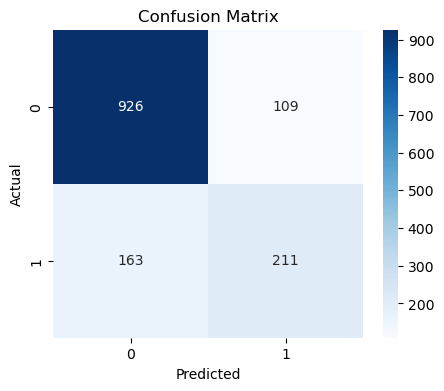

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

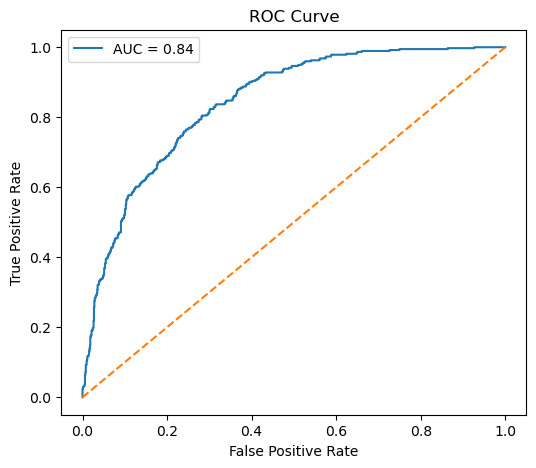

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

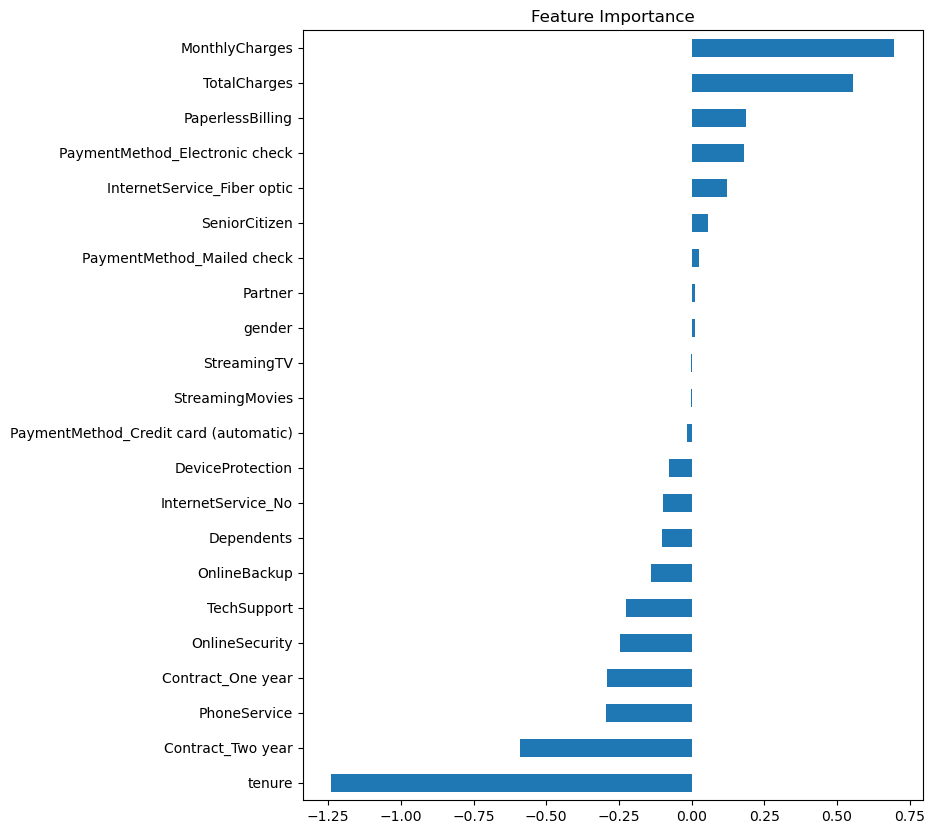

In [32]:
import pandas as pd

importance = pd.Series(
    model.coef_[0], 
    index=X.columns
).sort_values()

plt.figure(figsize=(8,10))
importance.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

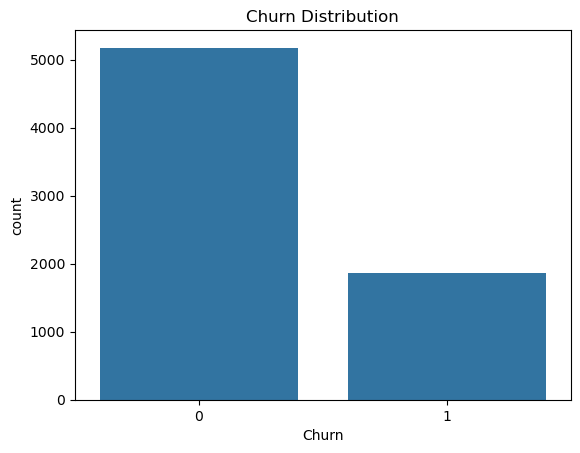

In [34]:
sns.countplot(x=y)
plt.title("Churn Distribution")
plt.show()